<a href="https://colab.research.google.com/github/ZahranAzariaAnvaya/ZahranAzariaAnvaya_2411531005_ML2526/blob/main/Praktikum1/MultipleLinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import pickle

In [8]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
df = pd.DataFrame(data= housing.data, columns=housing.feature_names)
df['MedHouseValue'] = pd.Series(housing.target)

targets=df['MedHouseValue']              #Dependent Variable
inputs=df.drop(['MedHouseValue'],axis=1) #Indendepeent Variable
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    inputs, targets,
    test_size=0.3,
    random_state=42
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Jumlah data training: 14448
Jumlah data testing: 6192


In [11]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train)
print(X_test)

[[0.25043103 0.66666667 0.03540957 ... 0.00184525 0.14680851 0.63047809]
 [0.16297706 0.37254902 0.02490651 ... 0.00106371 0.02553191 0.72310757]
 [0.2553551  0.45098039 0.03353176 ... 0.00150696 0.21702128 0.41932271]
 ...
 [0.16789424 0.68627451 0.02196727 ... 0.00212431 0.15744681 0.59462151]
 [0.35994676 0.2745098  0.03904731 ... 0.00200105 0.53510638 0.23804781]
 [0.14314285 1.         0.01782502 ... 0.00113982 0.55531915 0.19223108]]
[[8.14678418e-02 4.70588235e-01 2.34243862e-02 ... 2.56319369e-03
  3.73404255e-01 5.31872510e-01]
 [1.40094619e-01 5.68627451e-01 2.94319155e-02 ... 1.59940545e-03
  2.75531915e-01 4.87051793e-01]
 [2.05528200e-01 1.00000000e+00 2.18994569e-02 ... 5.37584539e-04
  5.58510638e-01 1.90239044e-01]
 ...
 [2.07728169e-01 2.94117647e-01 2.03757930e-02 ... 1.34975225e-03
  1.19148936e-01 6.41434263e-01]
 [2.17245279e-01 1.76470588e-01 3.27130659e-02 ... 2.29769634e-03
  5.60638298e-01 3.05776892e-01]
 [1.76004469e-01 3.13725490e-01 1.74931855e-02 ... 1.547

In [17]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Intercept:")
print(lr_model.intercept_)

print("\nSlope:")
for feature, coef in zip(inputs.columns, lr_model.coef_):
    print(feature, ":", coef)

Intercept:
3.6307047193242292

Slope:
MedInc : 6.464516361453108
HouseAge : 0.493775267281682
AveRooms : -17.21787731920547
AveBedrms : 19.700928184079107
Population : -0.027677641737723024
AveOccup : -4.187733397766801
Latitude : -3.9342454171058714
Longitude : -4.354227278281019


In [18]:
y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Mean Squared Error (MSE): 0.530567782476675
R2 Score: 0.5957702326061665


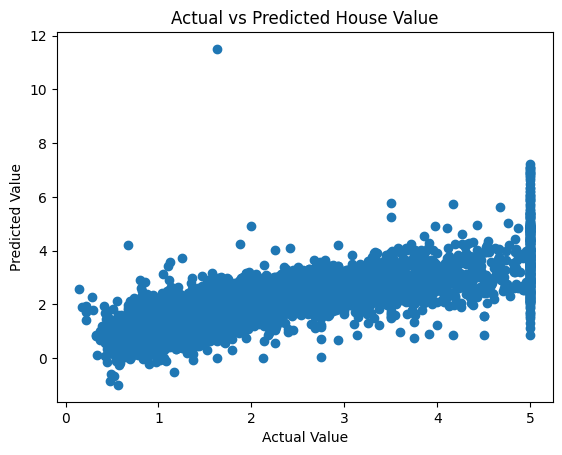

In [19]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted House Value")
plt.show()

In [22]:
import pickle
filename = 'finalized_model.sav'
pickle.dump(lr_model, open(filename, 'wb'))